## Setup Koneksi & Environmetn

In [1]:
import pandas as pd
import numpy as np

from supabase import create_client, Client
from pathlib import Path
import os
from dotenv import load_dotenv

# Dapatkan lokasi folder saat notebook ini berjalan
_notebook_dir = Path.cwd()

# Menyesuaikan path .env berdasarkan posisi notebook
if _notebook_dir.name == "notebooks":
    env_path = _notebook_dir.parent / ".env"
else:
    env_path = _notebook_dir / "backend" / ".env"

load_dotenv(env_path)

# Inisialisasi Supabase Client
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    print("Error: Kredensial Supabase tidak ditemukan di file .env")
else:
    supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
    print("Koneksi Supabase berhasil diinisiasi!")

Koneksi Supabase berhasil diinisiasi!


## Load All Data

In [2]:
def fetch_all(table, columns="*", page=1000):
    """Supabase membatasi 1000 baris/request, jadi diambil per halaman."""
    rows, start = [], 0
    while True:
        res = (supabase.table(table).select(columns)
               .order("recorded_date").order("card_id")
               .range(start, start + page - 1).execute())
        rows.extend(res.data)
        if len(res.data) < page:
            break
        start += page
    return pd.DataFrame(rows)

df_all = fetch_all("card_price_history")
df_all["recorded_date"] = pd.to_datetime(df_all["recorded_date"])

PRICE_COLS = [c for c in df_all.columns
              if c.startswith(("tcg_", "cardmarket_")) or c == "effective_market_price"]
df_all[PRICE_COLS] = df_all[PRICE_COLS].apply(pd.to_numeric, errors="coerce")
df_all = df_all.sort_values(["card_id", "recorded_date"]).reset_index(drop=True)

print(f"Baris: {len(df_all):,} | Kartu: {df_all['card_id'].nunique():,}")
print(f"Kolom harga: {PRICE_COLS}")

Baris: 233,283 | Kartu: 20,617
Kolom harga: ['tcg_normal_market', 'tcg_normal_low', 'tcg_normal_mid', 'tcg_normal_high', 'tcg_holo_market', 'tcg_holo_low', 'tcg_holo_mid', 'tcg_holo_high', 'tcg_reverse_market', 'cardmarket_trend', 'cardmarket_avg_sell', 'cardmarket_low', 'cardmarket_avg1', 'cardmarket_avg7', 'cardmarket_avg30', 'effective_market_price']


## Ringkasan Data Per Tanggal

In [3]:
per_day = (df_all.groupby("recorded_date")
           .agg(n_rows=("card_id", "size"), n_cards=("card_id", "nunique")))
print(per_day)
print("\nDuplikat (kartu+tanggal):", df_all.duplicated(["card_id", "recorded_date"]).sum())

               n_rows  n_cards
recorded_date                 
2026-09-22      20197    20197
2026-09-23      17132    17132
2026-09-24      16118    16118
2026-09-25      16867    16867
2026-09-28      18650    18650
2026-09-29      20617    20617
2026-09-30      20617    20617
2026-10-01      20617    20617
2026-10-02      20617    20617
2026-10-03      20617    20617
2026-10-04      20617    20617
2026-10-05      20617    20617

Duplikat (kartu+tanggal): 0


## Cek Perubahan Harga

In [4]:
chg = {}
for c in PRICE_COLS:
    diff = df_all.groupby("card_id")[c].diff()
    chg[c] = (diff.dropna() != 0).mean() * 100

print("% perubahan nilai antar tanggal, per kolom:")
print(pd.Series(chg).round(2).sort_values())

print("\nJam penulisan data per tanggal:")
print(df_all.groupby("recorded_date")["created_at"].agg(["min", "max"]))

% perubahan nilai antar tanggal, per kolom:
cardmarket_trend           0.00
cardmarket_avg_sell        0.00
cardmarket_low             0.00
cardmarket_avg1            0.00
cardmarket_avg7            0.00
cardmarket_avg30           0.00
tcg_normal_low             5.40
tcg_holo_low              17.97
tcg_holo_high             19.08
tcg_reverse_market        19.30
tcg_normal_mid            25.22
tcg_normal_market         27.45
tcg_normal_high           27.47
effective_market_price    32.05
tcg_holo_market           43.64
tcg_holo_mid              50.80
dtype: float64

Jam penulisan data per tanggal:
                                            min  \
recorded_date                                     
2026-09-22     2026-09-22T15:39:21.354218+00:00   
2026-09-23     2026-09-23T04:07:56.640254+00:00   
2026-09-24     2026-09-24T04:09:42.493078+00:00   
2026-09-25     2026-09-25T04:23:14.584012+00:00   
2026-09-28     2026-09-28T04:46:51.709505+00:00   
2026-09-29     2026-09-29T05:12:47.7488

## Deret harga TCGplayer per kartu

In [5]:
MKT_COLS = ["tcg_holo_market", "tcg_normal_market", "tcg_reverse_market"]

# Per kartu: pilih kolom varian dengan data terbanyak (seri), lalu pakai itu di semua tanggal
cnt = df_all.groupby("card_id")[MKT_COLS].count()
best_col = cnt.idxmax(axis=1)[cnt.max(axis=1) > 0]

df_all["price_usd"] = np.nan
for col in MKT_COLS:
    ids = best_col[best_col == col].index
    m = df_all["card_id"].isin(ids)
    df_all.loc[m, "price_usd"] = df_all.loc[m, col]

print("Kartu dengan deret harga TCGplayer:", df_all.loc[df_all["price_usd"].notna(), "card_id"].nunique())
print("Varian terpilih:\n", best_col.value_counts())

Kartu dengan deret harga TCGplayer: 18689
Varian terpilih:
 tcg_normal_market     11376
tcg_holo_market        7270
tcg_reverse_market       43
Name: count, dtype: int64


## Sinyal Teknikal / Momentum Jangka Pendek (Trend-Following)

Kartu dinilai: 18,687
signal
BUY     9182
SELL    7238
HOLD    2267
Name: count, dtype: int64

Top 10 Potensi BUY (Diskon Paling Besar dari Harga Wajar):
             card_id  last_price  predicted_price  chg_pct
18538    zsv10pt5-12        0.20            24.21    25.00
9913       smp-SM246        0.70            79.34    -1.41
10281       sv10-128        0.23            24.21    21.05
13066        svp-114        0.40            36.77    -6.98
3886         ex12-88        1.38            78.00     0.00
769           bw2-17        1.50            45.16     5.63
17959         xy7-41        0.03             0.89   -40.00
17022        xy10-50        0.15             3.96     7.14
16735  swshp-SWSH274        0.40            10.14     2.56
16628  swshp-SWSH167        0.25             6.25   -10.71

Top 10 Potensi SELL (Paling Overvalued / Kemahalan):
             card_id  last_price  predicted_price  chg_pct
6816         pop5-16     1900.00             6.46     0.00
6812         pop5-12     

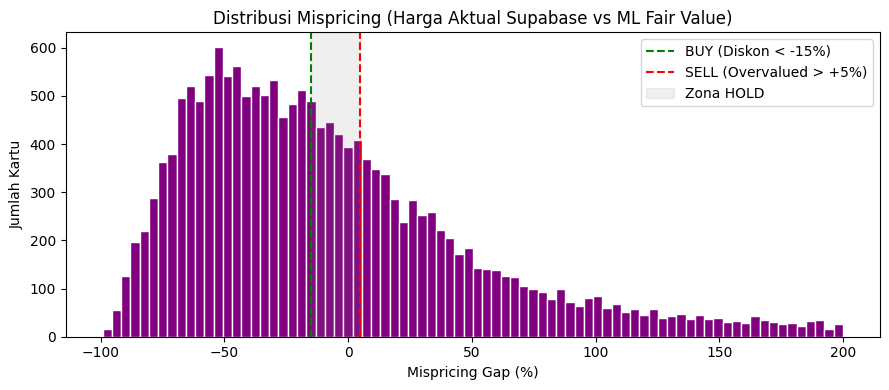

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Dapatkan harga terakhir (last_price) dari Supabase
latest = df_all["recorded_date"].max()
g = (df_all.dropna(subset=["price_usd"]).sort_values(["card_id", "recorded_date"]).groupby("card_id"))
mom = g.agg(n_days=("recorded_date", "nunique"), last_date=("recorded_date", "last"), 
            first_price=("price_usd", "first"), last_price=("price_usd", "last"))
mom = mom[(mom["n_days"] >= 4) & (mom["last_date"] == latest) & (mom["last_price"] > 0)].copy()
mom["chg_pct"] = (mom["last_price"] / mom["first_price"] - 1) * 100
mom = mom.reset_index()

# 2. Load Data Master & Latih Model ML (Untuk Mendapatkan Fair Value)
df_master = pd.read_csv("../dataset/pokemon_cards_dataset_cleaned.csv")
df_master['age'] = 2024 - df_master['release_year']
df_master['rarity_enc'] = df_master['rarity'].astype('category').cat.codes
df_master['supertype_enc'] = df_master['supertype'].astype('category').cat.codes
df_master['hp'] = df_master['hp'].fillna(0)

# Proses Training ML cepat (Menggunakan target Logaritma)
df_train = df_master.dropna(subset=['effective_market_price'])
X = df_train[['rarity_enc', 'supertype_enc', 'age', 'hp']]
y = np.log1p(df_train['effective_market_price'])
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 3. Gabungkan Harga Aktual Supabase dengan Tebakan ML
mom = pd.merge(mom, df_master[['card_id', 'rarity_enc', 'supertype_enc', 'age', 'hp']], on='card_id', how='inner')
mom['predicted_price'] = np.expm1(rf.predict(mom[['rarity_enc', 'supertype_enc', 'age', 'hp']]))

# 4. ENGINE MISPRICING: (Harga Aktual - Harga ML) / Harga ML
mom['mispricing_gap'] = (mom['last_price'] - mom['predicted_price']) / mom['predicted_price']

# 5. Tetapkan Sinyal: BUY jika diskon di bawah -15%, SELL jika kemahalan di atas +5%
mom["signal"] = np.select(
    [mom["mispricing_gap"] < -0.15, mom["mispricing_gap"] > 0.05], 
    ["BUY", "SELL"], 
    default="HOLD"
)

# --- CETAK HASIL ---
print(f"Kartu dinilai: {len(mom):,}")
print(mom["signal"].value_counts())

# Untuk Mispricing, kita mencari kartu yang Gap-nya paling negatif (Murah) untuk di-BUY
print("\nTop 10 Potensi BUY (Diskon Paling Besar dari Harga Wajar):")
print(mom[mom.signal == "BUY"].nsmallest(10, "mispricing_gap")[['card_id', 'last_price', 'predicted_price', 'chg_pct']].round(2))

# Untuk SELL, kita mencari kartu yang Gap-nya paling positif (Kemahalan)
print("\nTop 10 Potensi SELL (Paling Overvalued / Kemahalan):")
print(mom[mom.signal == "SELL"].nlargest(10, "mispricing_gap")[['card_id', 'last_price', 'predicted_price', 'chg_pct']].round(2))


# 6. HISTOGRAM DISTRIBUSI MISPRICING
# Dipotong rentangnya (-100% s/d +200%) agar outlier ekstrim tidak merusak grafik
plot_data = mom.loc[mom["mispricing_gap"].between(-1, 2), "mispricing_gap"] * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(plot_data, bins=80, color="purple", edgecolor="white")
ax.axvline(-15, color="green", ls="--", label="BUY (Diskon < -15%)")
ax.axvline(5,  color="red",   ls="--", label="SELL (Overvalued > +5%)")
ax.axvspan(-15, 5, color="gray", alpha=0.12, label="Zona HOLD")
ax.set_title("Distribusi Mispricing (Harga Aktual Supabase vs ML Fair Value)")
ax.set_xlabel("Mispricing Gap (%)")
ax.set_ylabel("Jumlah Kartu")
ax.legend()
plt.tight_layout()
plt.show()

## Forecasting Harga (Data Kontinu)

In [8]:
# ======================================================================
# MODEL FORECASTING MASA DEPAN (Hybrid Time-Series + Panel Data)
# ======================================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load data CSV fundamental fisik kartu (Rarity, dll)
df_master = pd.read_csv("../dataset/pokemon_cards_dataset_cleaned.csv")
df_master['age'] = 2024 - df_master['release_year']

# Encode kolom teks jadi angka
df_master['rarity_enc'] = df_master['rarity'].astype('category').cat.codes
df_master['supertype_enc'] = df_master['supertype'].astype('category').cat.codes

# 2. Buat Lag Features (Harga H-1 dan H-2) dari Data Supabase (df_all)
df_lag = df_all[['recorded_date', 'card_id', 'price_usd']].copy()
df_lag = df_lag.dropna(subset=['price_usd']).sort_values(['card_id', 'recorded_date'])

df_lag['price_lag_1'] = df_lag.groupby('card_id')['price_usd'].shift(1)
df_lag['price_lag_2'] = df_lag.groupby('card_id')['price_usd'].shift(2)
df_lag = df_lag.dropna(subset=['price_lag_1', 'price_lag_2']) # Buang data awal yang kosong

# 3. Gabungkan Data Supabase + Data Fisik Kartu
df_combined = pd.merge(df_lag, df_master[['card_id', 'rarity_enc', 'supertype_enc', 'age', 'hp']], on='card_id', how='left')
df_combined['hp'] = df_combined['hp'].fillna(0) # Isi HP kartu Trainer/Energy dengan 0

# 4. Splitting & Training (Forecasting Model)
X = df_combined[['price_lag_1', 'price_lag_2', 'rarity_enc', 'supertype_enc', 'age', 'hp']]
y = np.log1p(df_combined['price_usd']) # Tetap pakai log untuk meratakan lonjakan harga

# Memisahkan 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Latih Random Forest
forecast_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forecast_model.fit(X_train, y_train)

# 5. Evaluasi Hasil (Balikkan nilai Log ke Dollar asli)
y_pred_dollar = np.expm1(forecast_model.predict(X_test))
y_test_dollar = np.expm1(y_test)

print("✅ Model Forecasting Hybrid (Time-Series + Fundamental) Berhasil Dilatih!")
print(f"R2 Score Forecasting : {r2_score(y_test_dollar, y_pred_dollar):.4f}")
print(f"Mean Absolute Error  : ${mean_absolute_error(y_test_dollar, y_pred_dollar):.2f}")

✅ Model Forecasting Hybrid (Time-Series + Fundamental) Berhasil Dilatih!
R2 Score Forecasting : 0.9968
Mean Absolute Error  : $0.23
